In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


In [2]:
CSV_PATH  = "Remaining_GPCRs/ADRA1A_coding_variants.csv"   # ← path to your file
GENE_NAME = "ADRA1A"    

In [3]:
COLOR_MAP = {
    # Coding changes
    "missense_variant":                    "#7F77DD",   # purple
    "synonymous_variant":                  "#3DA876",   # green
    "stop_gained":                         "#E24B4A",   # red
    "stop_lost":                           "#B03A2E",   # dark red
    "start_lost":                          "#E8740C",   # orange-red
    "frameshift_variant":                  "#D4537E",   # pink
    "inframe_insertion":                   "#EF9F27",   # amber
    "inframe_deletion":                    "#C97B1A",   # dark amber
    "splice_region_variant":               "#FFFF00",
}
 
LABEL_MAP = {
    "missense_variant":                    "Missense",
    "synonymous_variant":                  "Synonymous",
    "stop_gained":                         "Stop gained",
    "stop_lost":                           "Stop lost",
    "start_lost":                          "Start lost",
    "frameshift_variant":                  "Frameshift",
    "inframe_insertion":                   "Inframe insertion",
    "inframe_deletion":                    "Inframe deletion",
    "splice_region_variant":               "Splice variant",
}

In [4]:
df = pd.read_csv(CSV_PATH)
 
# Build a lowercase lookup so we can find columns regardless of
# capitalisation or minor spelling differences
col_lookup = {c.lower().strip(): c for c in df.columns}
 
def find_col(keywords):
    """Return the first column name whose lowercased version contains
    any of the given keywords. Raises an error if nothing matches."""
    for kw in keywords:
        for low, orig in col_lookup.items():
            if kw in low:
                return orig
    raise KeyError(f"Could not find a column matching any of: {keywords}\n"
                   f"Available columns: {list(df.columns)}")
 
COL_POSITION   = find_col(["protein position", "protein_position"])
COL_AA         = find_col(["amino acid change", "amino acid"])
COL_CONS       = find_col(["conseq"])
COL_FREQ       = find_col(["allele freq", "allele frequency"])
 
# Keep only rows that have a protein position (skip UTR / intergenic)
df = df[df[COL_POSITION].astype(str).str.strip() != "-"].copy()
df[COL_POSITION] = pd.to_numeric(df[COL_POSITION], errors="coerce")
df = df.dropna(subset=[COL_POSITION])
df[COL_POSITION] = df[COL_POSITION].astype(int)
 
# If a row has two consequences (comma-separated), keep only the first
df[COL_CONS] = df[COL_CONS].astype(str).str.split(",").str[0].str.strip()
 
# Label shown next to each bar, e.g. "Y/D332"
df["label"] = df[COL_AA].astype(str) + df[COL_POSITION].astype(str)
 
# Map consequence → color (unknown types get grey)
df["color"] = df[COL_CONS].map(COLOR_MAP).fillna("#AAAAAA")

KeyError: "Could not find a column matching any of: ['allele freq', 'allele frequency']\nAvailable columns: ['Location', 'Affected Allele', 'Other Allele', 'Consequences', 'Protein Position', 'Amino Acid Change', 'Codons', 'P Value', 'Negative LogP Value']"

In [24]:
# Use the order defined in COLOR_MAP so related types sit together
GROUP_ORDER = list(COLOR_MAP.keys())
df["sort_key"] = df[COL_CONS].map(
    {k: i for i, k in enumerate(GROUP_ORDER)}
).fillna(99)
 
df = df.sort_values(
    ["sort_key", COL_FREQ], ascending=[True, True]
).reset_index(drop=True)

In [25]:
N             = len(df)
N_GROUPS      = df[COL_CONS].nunique()
 
# Reserve 15% of the full circle as blank gaps between groups.
# With many groups the gaps are smaller; with few groups, larger.
GAP_TOTAL     = 0.15 * 2 * np.pi
ARC_PER_BAR   = (2 * np.pi - GAP_TOTAL) / N
GAP_PER_GROUP = GAP_TOTAL / N_GROUPS
 
angles        = []
current_angle = np.pi / 2    # start at 12 o'clock
prev_group    = None
 
for _, row in df.iterrows():
    group = row[COL_CONS]
    # Insert a gap every time the consequence group changes
    if prev_group is not None and group != prev_group:
        current_angle += GAP_PER_GROUP
    angles.append(current_angle + ARC_PER_BAR / 2)
    current_angle += ARC_PER_BAR
    prev_group = group
 
df["angle"] = angles
 

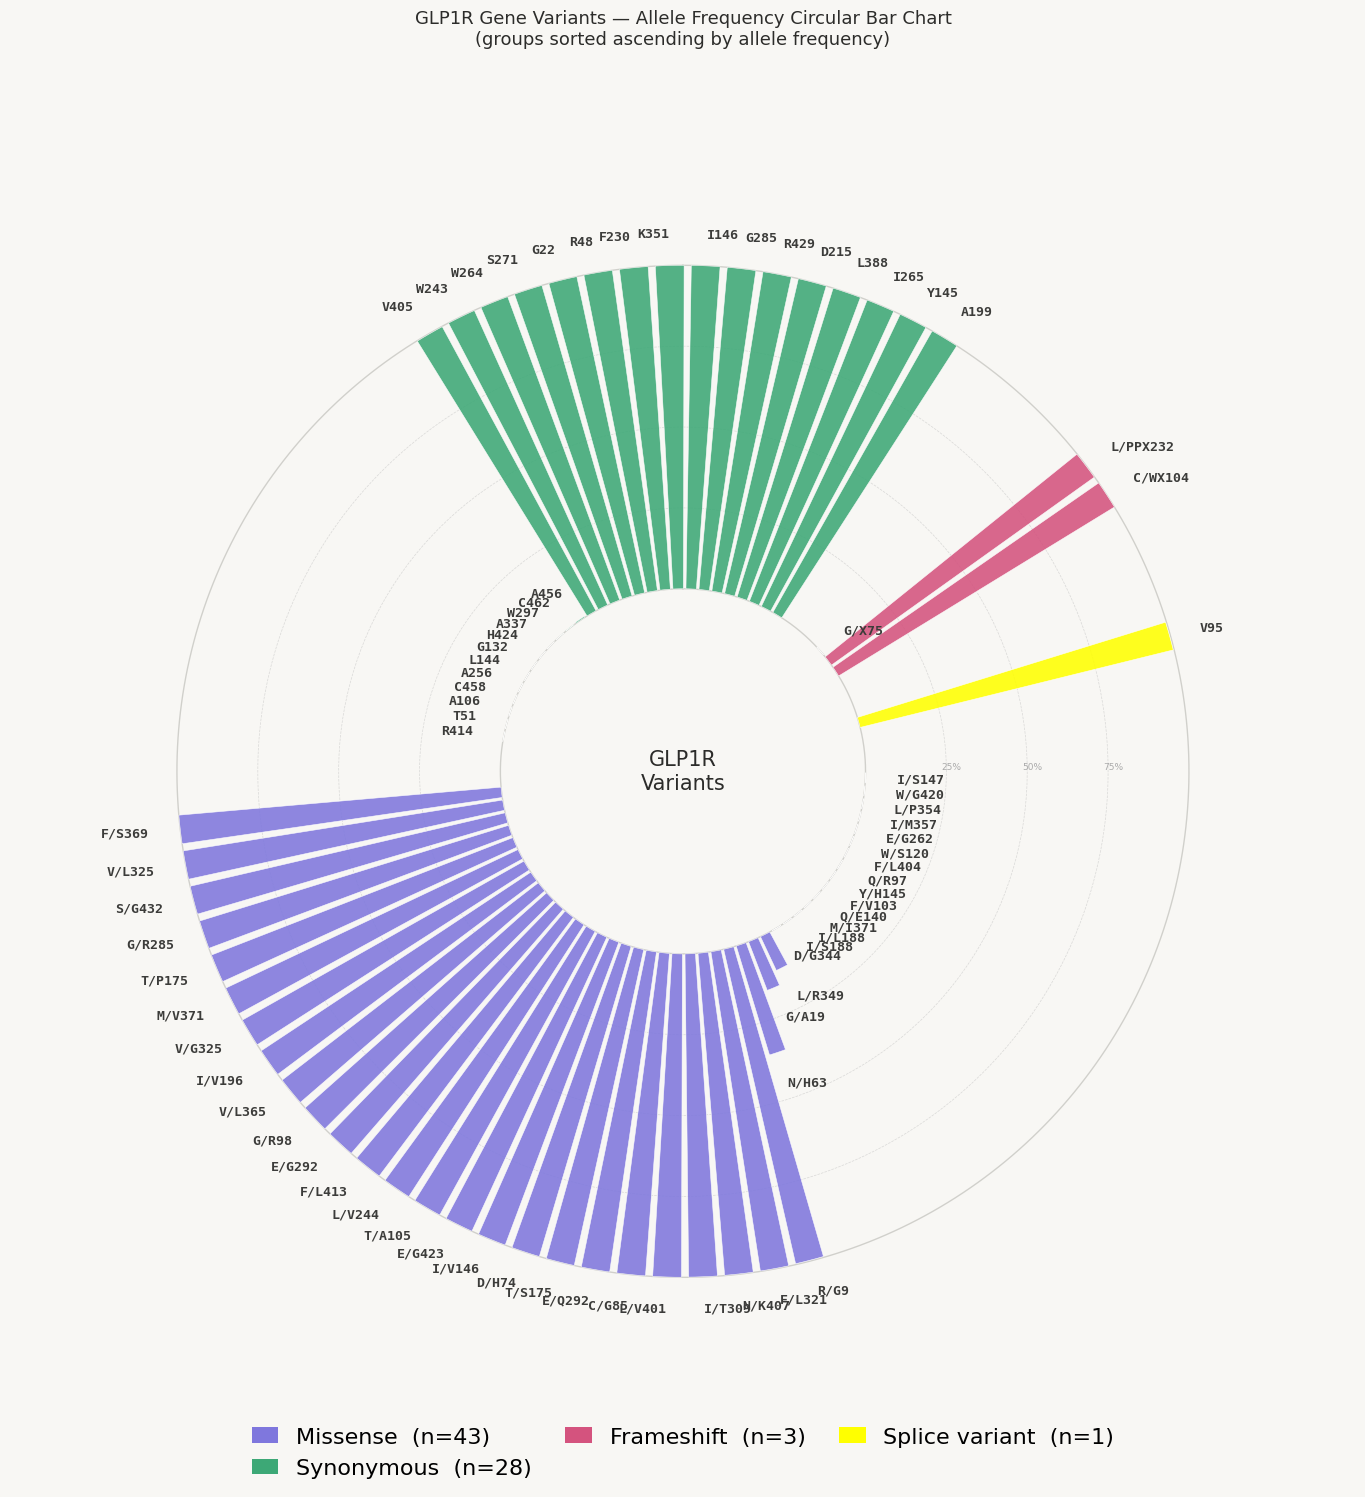

Saved: glp1r_circular_barplot.png


In [26]:
INNER_R = 0.35    # radius of the empty centre ring
BAR_MAX = 0.62    # bar height when allele frequency = 1.0
OUTER_R = INNER_R + BAR_MAX
 
fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={"projection": "polar"})
fig.patch.set_facecolor("#F8F7F4")
ax.set_facecolor("#F8F7F4")
ax.set_theta_zero_location("N")   # 0° at the top (12 o'clock)
ax.set_theta_direction(-1)        # clockwise
ax.set_ylim(0, OUTER_R + 0.32)
ax.axis("off")                    # hide default polar axes / ticks
 
# ── Inner and outer reference rings ──────────────────────────
for radius in [INNER_R, OUTER_R]:
    ax.plot(np.linspace(0, 2*np.pi, 360), [radius] * 360,
            color="#888880", lw=1, alpha=0.35, zorder=0)
 
# ── Dashed frequency grid at 25 / 50 / 75% ──────────────────
for pct in [0.25, 0.50, 0.75]:
    r = INNER_R + pct * BAR_MAX
    ax.plot(np.linspace(0, 2*np.pi, 360), [r] * 360,
            color="#BBBBBB", lw=0.5, ls="--", alpha=0.5, zorder=0)
    ax.text(np.pi / 2, r + 0.01, f"{int(pct * 100)}%",
            ha="center", va="bottom", fontsize=6.5, color="#AAAAAA")
 
# ── Bars ─────────────────────────────────────────────────────
bar_width = ARC_PER_BAR * 0.80   # slight gap between adjacent bars
 
for _, row in df.iterrows():
    bar_height = row[COL_FREQ] * BAR_MAX
    ax.bar(
        row["angle"], bar_height,
        width=bar_width, bottom=INNER_R,
        color=row["color"], alpha=0.88,
        edgecolor="white", linewidth=0.4,
        zorder=3
    )
 
# ── Labels — horizontal, pointing away from centre ───────────
for _, row in df.iterrows():
    angle   = row["angle"]
    tip_r   = INNER_R + row[COL_FREQ] * BAR_MAX
    label_r = tip_r + 0.06
 
    # Determine which side of the circle we are on
    x  = label_r * np.cos(np.pi / 2 - angle)
    ha = "left" if x >= 0 else "right"
 
    ax.text(
        angle, label_r, row["label"],
        rotation=0,            # always horizontal (parallel to x-axis)
        ha=ha, va="center",
        fontsize=9.5, color="#3C3C3A",
        fontfamily="monospace", zorder=6,
        fontweight="bold"
    )
 
# ── Gene name in the centre ───────────────────────────────────
ax.text(0, 0, f"{GENE_NAME}\nVariants",
        ha="center", va="center",
        fontsize=15, fontweight="500", color="#2C2C2A", zorder=10)
 
# =============================================================
#  STEP 5 — Legend (only shows consequence types present in data)
# =============================================================
present_cons = df[COL_CONS].unique()
 
legend_patches = []
for cons, color in COLOR_MAP.items():
    count = (df[COL_CONS] == cons).sum()
    if count > 0:
        label = f"{LABEL_MAP.get(cons, cons)}  (n={count})"
        legend_patches.append(
            mpatches.Patch(facecolor=color, edgecolor="none", label=label)
        )
 
# Arrange legend in up to 3 columns
n_cols = min(3, len(legend_patches))
ax.legend(
    handles=legend_patches,
    loc="lower center", bbox_to_anchor=(0.5, -0.04),
    ncol=n_cols, frameon=False,
    fontsize=16, handlelength=1.2, columnspacing=1.5
)
 
# =============================================================
#  STEP 6 — Save
# =============================================================
plt.title(
    f"{GENE_NAME} Gene Variants — Allele Frequency Circular Bar Chart\n"
    "(groups sorted ascending by allele frequency)",
    fontsize=13, fontweight="500", color="#2C2C2A", pad=20
)
plt.tight_layout()
 
output_file = f"{GENE_NAME.lower()}_circular_barplot.png"
plt.savefig(output_file, dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"Saved: {output_file}")